In [61]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import scipy.optimize as opt
matplotlib.rcParams.update({'font.size': 13})
matplotlib.rcParams['lines.linewidth'] = 2
plt.rcParams['axes.formatter.limits'] = (-3, 3)
#plt.rcParams['axes.formatter.limits'] = plt.rcParamsDefault['axes.formatter.limits']
plt.rcParams['axes.formatter.use_mathtext'] = True


light_green = (0.4, 0.8, 0.2)
dark_purple = (0.4, 0.3, 0.7)
raspberry_pink = (1, 0, 0.5)


# Дисперсия стекла

In [62]:
# параметры
# погрешность измерения углов
delta1 = 5 # секунд (приборная)
delta2 = (130 - 60)/2 # секунд (систематическая)

# начальный угол
a0 = int((60 + 130)/2)

# угол при вершине призмы
a = 180 * 3600 - 423394 # секунд
delta_a = 2*delta1 # секунд
(a//3600, a%3600//60, a%60)


(62, 23, 26)

In [63]:
data1 = pd.read_excel("измерения.xlsx", sheet_name="измерение спектра")[["lambda, nm", "градусы", "минуты", "секунды"]].dropna()
data1[["градусы", "минуты", "секунды"]] = data1[["градусы", "минуты", "секунды"]].astype(int)
data1["суммсек абс"] = 360 * 3600 - (data1["градусы"] * 3600 + data1["минуты"] * 60 + data1["секунды"]) + a0
data1["градусы абс"] = data1["суммсек абс"]//3600
data1["минуты абс"] = (data1["суммсек абс"]%3600)//60
data1["секунды абс"] = data1["суммсек абс"]%60
data1

,"lambda, nm",градусы,минуты,секунды,суммсек абс,градусы абс,минуты абс,секунды абс
0,579.1,308,3,49,187066,51,57,46
1,577.0,308,2,12,187163,51,59,23
2,546.1,307,42,12,188363,52,19,23
3,491.6,306,55,22,191173,53,6,13
4,435.8,305,42,52,195523,54,18,43
5,404.7,304,45,33,198962,55,16,2
6,623.4,308,26,57,185678,51,34,38
7,690.7,308,53,45,184070,51,7,50


In [64]:
data1["n"] = np.sin((a + data1["суммсек абс"])/2 / 3600 /180 * np.pi)/np.sin(a/2 / 3600 /180 * np.pi)
data1["delta_n"] = ((np.cos((a + data1["суммсек абс"])/2/3600/180*np.pi)/2/np.sin(a/2/3600/180*np.pi))**2 * ((2*delta1 + delta2)/3600/180*np.pi)**2 + 
                    (np.sin(data1["суммсек абс"]/2/3600/180*np.pi)/2/np.sin(a/2/3600/180*np.pi))**2 * (delta_a/3600/180*np.pi)**2)**0.5
data1 = data1.sort_values('lambda, nm')
data1


,"lambda, nm",градусы,минуты,секунды,суммсек абс,градусы абс,минуты абс,секунды абс,n,delta_n
5,404.7,304,45,33,198962,55,16,2,1.651925,0.000111
4,435.8,305,42,52,195523,54,18,43,1.643537,0.000113
3,491.6,306,55,22,191173,53,6,13,1.632764,0.000114
2,546.1,307,42,12,188363,52,19,23,1.625708,0.000115
1,577.0,308,2,12,187163,51,59,23,1.622672,0.000116
0,579.1,308,3,49,187066,51,57,46,1.622426,0.000116
6,623.4,308,26,57,185678,51,34,38,1.618895,0.000117
7,690.7,308,53,45,184070,51,7,50,1.614783,0.000117


3.723922281586374e-07 5.085669195548472e-09 -0.0005328300247139297 5.5098623653151514e-06 1.8057081511457254 5.5098623653151514e-06


(-0.0001307345813062306, 4.516653852062627e-07)

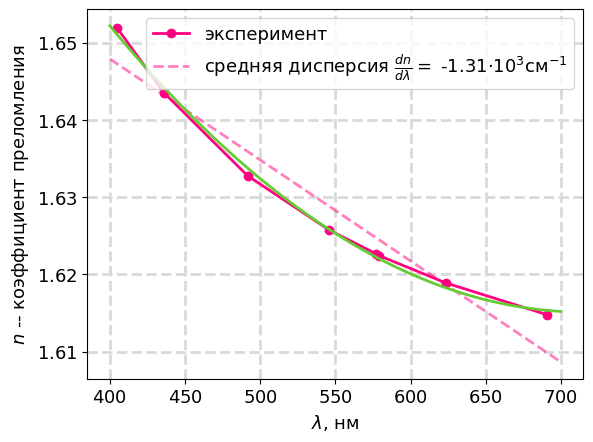

In [73]:
# расчет cредней дисперсии
def linear(x, k, b):
    return k*x + b
popt, pcov = opt.curve_fit(linear, 
                             data1["lambda, nm"], 
                             data1["n"], 
                             sigma = data1["delta_n"], 
                             absolute_sigma = True)
k = popt[0]
b = popt[1]
delta_k = pcov[0][0]**0.5
delta_b = pcov[1][1]**0.5

# аппроксимация полиномом
def square(x, c, d, e):
    return c*x**2 + d*x + e
popt, pcov = opt.curve_fit(square, 
                             data1["lambda, nm"], 
                             data1["n"], 
                             sigma = data1["delta_n"], 
                             absolute_sigma = True)
c = popt[0]
d = popt[1]
e = popt[2]
delta_c = pcov[0][0]**0.5
delta_d = pcov[1][1]**0.5
delta_e = pcov[2][2]**0.5
print(c, delta_c, d, delta_d, e, delta_d)


n0 = 0

x_th = np.linspace(400, 700, 100)

plt.grid(c = (0.85, 0.85, 0.85), ls = '--', lw = 2)

plt.plot(data1["lambda, nm"], data1["n"] - n0, 'o-', 
         color = raspberry_pink, 
         label = 'эксперимент')
plt.plot(x_th, k * x_th + b - n0, 
         color = raspberry_pink, ls = '--', alpha = 0.5,
         label = r"средняя дисперсия $\frac{dn}{d\lambda} =$" + f' {k*1e4:.2f}' + r'$\cdot 10^{3} \text{см}^{-1}$')
plt.plot(x_th, square(x_th, c, d, e) - n0,
         color = light_green)

plt.xlabel(r"$\lambda$, нм")
plt.ylabel(r"$n$ -- коэффициент преломления")
plt.legend()
k, delta_k


In [ ]:
# число аббе
nF = square(486.1, c, d, e) # голубая линия водорода
nD = square(589.8, c, d, e) # желтый дублет натрия
nC = square(656.3, c, d, e) # красная линия водорода
(nD - 1)/(nF - nC)

33.96890725274231